In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

con = duckdb.connect()
CSV_PATH = "../output/csv"

cohort = con.execute(f"""
    WITH inpatient AS (
        SELECT
            Id AS encounter_id,
            PATIENT,
            START AS admit_date,
            STOP AS discharge_date,
            REASONDESCRIPTION AS reason
        FROM read_csv_auto('{CSV_PATH}/encounters.csv')
        WHERE ENCOUNTERCLASS = 'inpatient'
    ),
    readmissions AS (
        SELECT
            a.PATIENT,
            a.encounter_id AS index_encounter,
            a.discharge_date AS index_discharge,
            b.admit_date AS readmit_date,
            DATEDIFF('day', a.discharge_date, b.admit_date) AS das_to_readmit,
            a.reason AS index_reason
        FROM inpatient a
        JOIN inpatient b
            ON a.PATIENT = b.PATIENT
            AND b.admit_date > a.discharge_Date
            AND DATEDIFF ('day', a.discharge_date, b.admit_date) <= 30
            AND a.encounter_id != b.encounter_id
    )
    SELECT
        r.*,
        p.GENDER,
        p.RACE,
        p.BIRTHDATE,
        DATE_DIFF('year', CAST(p.BIRTHDATE AS DATE), CAST(r.index_discharge AS DATE)) AS age_at_discharge
    FROM readmissions r
    JOIN read_csv_auto('{CSV_PATH}/patients.csv') p
        ON r.PATIENT = p.Id
""").df()

lung_cancer_patients = cohort[cohort['index_reason'].str.contains('Non-small cell carcinoma', na=False)]['PATIENT'].unique()
non_chemo_cohort = cohort[~cohort['PATIENT'].isin(lung_cancer_patients)]

print("Cohort rebuilt:", cohort.shape)
print("Non-chemo cohort:", non_chemo_cohort.shape)

Cohort rebuilt: (165, 10)
Non-chemo cohort: (37, 10)


<function matplotlib.pyplot.show(close=None, block=None)>

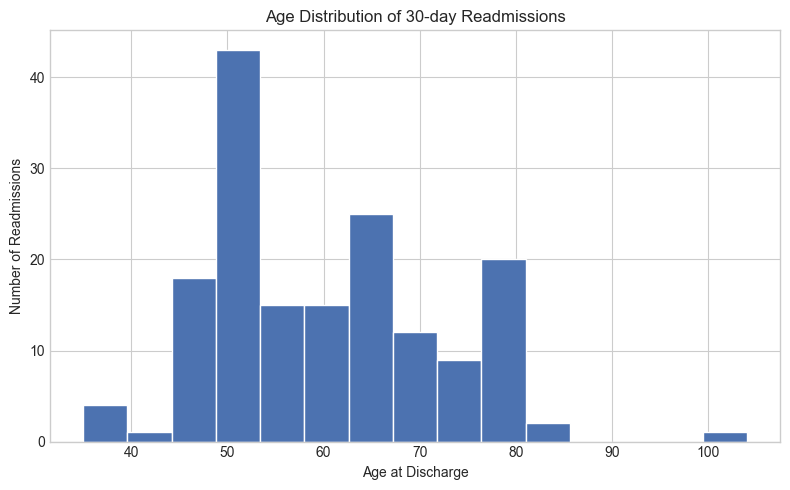

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(cohort['age_at_discharge'], bins = 15, color='#4C72b0', edgecolor='white')
ax.set_xlabel('Age at Discharge')
ax.set_ylabel('Number of Readmissions')
ax.set_title('Age Distribution of 30-day Readmissions')
plt.tight_layout()
plt.savefig('../reports/age_distribution.png', dpi = 150)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

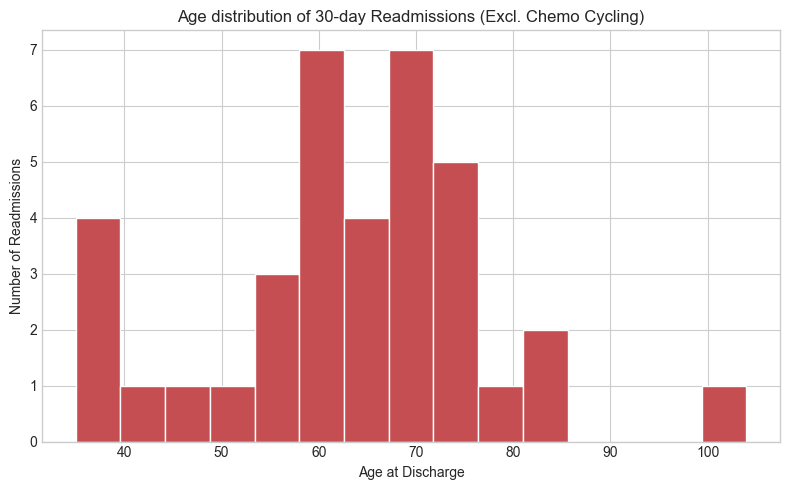

In [3]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(non_chemo_cohort['age_at_discharge'], bins=15, color='#C44E52', edgecolor='white')
ax.set_xlabel('Age at Discharge')
ax.set_ylabel('Number of Readmissions')
ax.set_title('Age distribution of 30-day Readmissions (Excl. Chemo Cycling)')
plt.tight_layout()
plt.savefig('../reports/age_distribution_adjusted.png', dpi=150)
plt.show

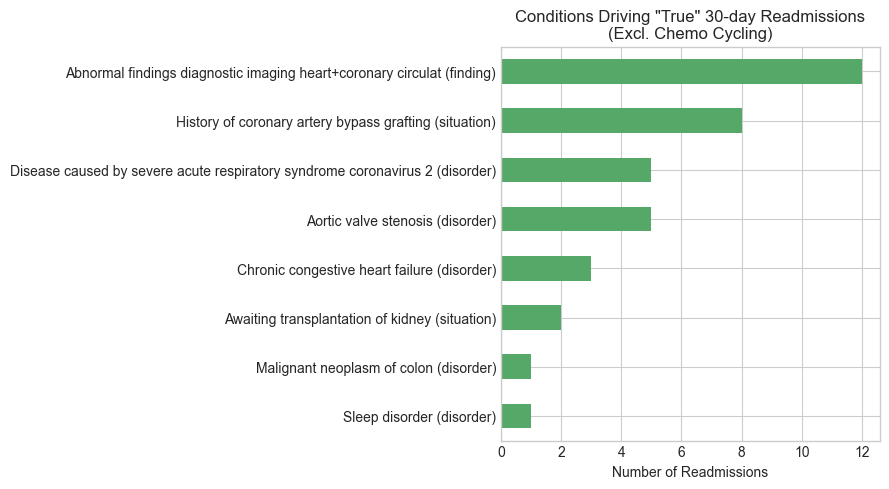

In [4]:
top_conditions_excl = non_chemo_cohort.groupby('index_reason').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize = (9,5))
top_conditions_excl.plot(kind='barh', ax=ax, color='#55A868')
ax.set_xlabel('Number of Readmissions')
ax.set_ylabel('')
ax.set_title('Conditions Driving "True" 30-day Readmissions\n(Excl. Chemo Cycling)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/top_conditions_adjusted.png', dpi=150)
plt.show()

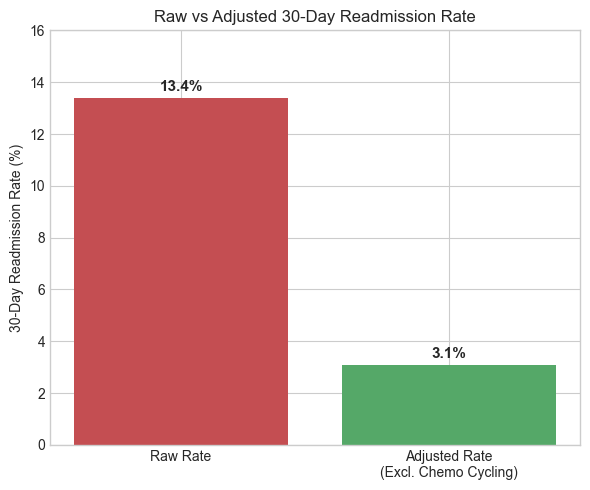

In [8]:
rates = pd.DataFrame({
    'Metric': ['Raw Rate', 'Adjusted Rate\n(Excl. Chemo Cycling)'],
    'Readmission Rate (%)': [13.4, 3.1]
})

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(rates['Metric'], rates['Readmission Rate (%)'], color=['#C44E52', '#55A868'])
ax.set_ylabel('30-Day Readmission Rate (%)')
ax.set_title('Raw vs Adjusted 30-Day Readmission Rate')
ax.set_ylim(0,16)

# value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                                 xytext=(0,5), textcoords='offset points', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/raw_vs_adjusted_rate.png', dpi=150)
plt.show()